#Khushi Das (2435778)

In [ ]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version :", tf.__version__)
print("Keras version       :", tf.keras.__version__)

TensorFlow version : 2.19.0
Keras version       : 3.13.2


In [ ]:
ZIP_PATH    = "/content/Copy of devnagari digit.zip"
EXTRACT_DIR = "/content/dataset"

# Extract the zip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)
print("Extracted to:", EXTRACT_DIR)

# Auto-detect Train / Test folders inside the extracted contents
train_dir = None
test_dir  = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    if "Train" in dirs and "Test" in dirs:
        train_dir = os.path.join(root, "Train")
        test_dir  = os.path.join(root, "Test")
        break
    if "train" in dirs and "test" in dirs:
        train_dir = os.path.join(root, "train")
        test_dir  = os.path.join(root, "test")
        break

print("Train folder:", train_dir)
print("Test  folder:", test_dir)
print("Train classes:", sorted(os.listdir(train_dir)))

Extracted to: /content/dataset
Train folder: /content/dataset/DevanagariHandwrittenDigitDataset/Train
Test  folder: /content/dataset/DevanagariHandwrittenDigitDataset/Test
Train classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


Loading training data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading test data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Training set : (17000, 28, 28, 1)  Labels: (17000, 10)
Test set     : (3000, 28, 28, 1)   Labels: (3000, 10)
Pixel range  : [0.00, 1.00]


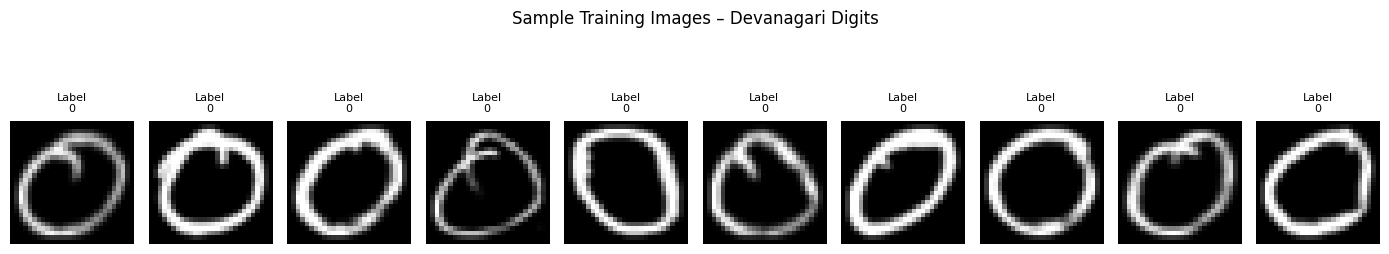

In [ ]:
IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """
    Loads images from subfolders (each subfolder = one class).
    Returns normalised numpy arrays and integer labels.
    """
    images      = []
    labels      = []
    class_names = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])
    class_map = {name: idx for idx, name in enumerate(class_names)}
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label      = class_map[class_name]

        for filename in os.listdir(class_path):
            if not filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                continue
            img_path = os.path.join(class_path, filename)
            try:
                img       = Image.open(img_path).convert("L")        # grayscale
                img       = img.resize((IMG_WIDTH, IMG_HEIGHT))       # 28×28
                img_array = np.array(img) / 255.0                    # normalise [0,1]
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


# Load datasets
print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("\nLoading test data...")
x_test_raw, y_test_raw   = load_images_from_folder(test_dir)

# Reshape for Keras: (N, 28, 28) → (N, 28, 28, 1)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test_raw .reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"Training set : {x_train.shape}  Labels: {y_train.shape}")
print(f"Test set     : {x_test.shape}   Labels: {y_test.shape}")
print(f"Pixel range  : [{x_train.min():.2f}, {x_train.max():.2f}]")

# Visualise 10 sample images
plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    plt.title(f"Label\n{np.argmax(y_train[i])}", fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Training Images – Devanagari Digits", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Model: "FCN_Devanagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

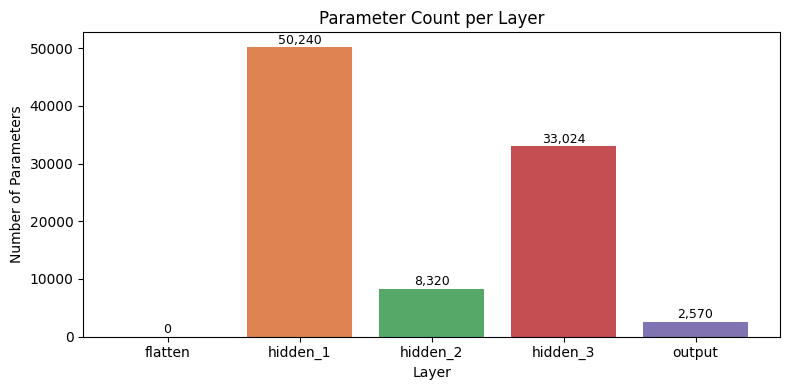

Total trainable parameters: 94,154


In [ ]:
def build_fcn_model(input_shape=(28, 28, 1), num_classes=10):
    """
    Fully Connected Network (Sequential API):
        Input -> Flatten -> Dense(64,sigmoid) -> Dense(128,sigmoid)
              -> Dense(256,sigmoid) -> Dense(10, softmax)
    """
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),

        keras.layers.Flatten(name="flatten"),

        keras.layers.Dense(64,  activation="sigmoid", name="hidden_1"),
        keras.layers.Dense(128, activation="sigmoid", name="hidden_2"),
        keras.layers.Dense(256, activation="sigmoid", name="hidden_3"),

        keras.layers.Dense(num_classes, activation="softmax", name="output"),
    ], name="FCN_Devanagari")

    return model


model = build_fcn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=NUM_CLASSES)
model.summary()

# Parameter count bar chart
layer_names  = [l.name for l in model.layers]
param_counts = [l.count_params() for l in model.layers]

plt.figure(figsize=(8, 4))
bars = plt.bar(layer_names, param_counts,
               color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"])
plt.xlabel("Layer")
plt.ylabel("Number of Parameters")
plt.title("Parameter Count per Layer")
for bar, count in zip(bars, param_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print(f"Total trainable parameters: {model.count_params():,}")

In [ ]:
model.compile(
    optimizer="adam",                  # Adam: adaptive, works well for most tasks
    loss="categorical_crossentropy",   # multi-class loss for one-hot encoded labels
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print(f"  Optimizer : Adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metric    : accuracy")

Model compiled successfully.
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metric    : accuracy


In [ ]:
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2
CHECKPOINT_PATH  = "/content/best_model.keras"

callbacks = [
    # Save the best model based on lowest validation loss
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    # Stop early if val_loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

print("Starting training...\n")
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1,
)
print("\nTraining complete.")

Starting training...

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2794 - loss: 1.9592
Epoch 1: val_loss improved from None to 7.10545, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4602 - loss: 1.5900 - val_accuracy: 0.0000e+00 - val_loss: 7.1055
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7963 - loss: 0.6731
Epoch 2: val_loss did not improve from 7.10545
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8272 - loss: 0.5574 - val_accuracy: 0.0000e+00 - val_loss: 8.2872
Epoch 3/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8974 - loss: 0.3482
Epoch 3: val_loss did not improve from 7.10545
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9135 - loss: 0.3004 - val_accuracy: 0.0000e+00 - val_loss: 8.9544
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9382 - loss: 0.2134
Epoch 4: val_loss did n

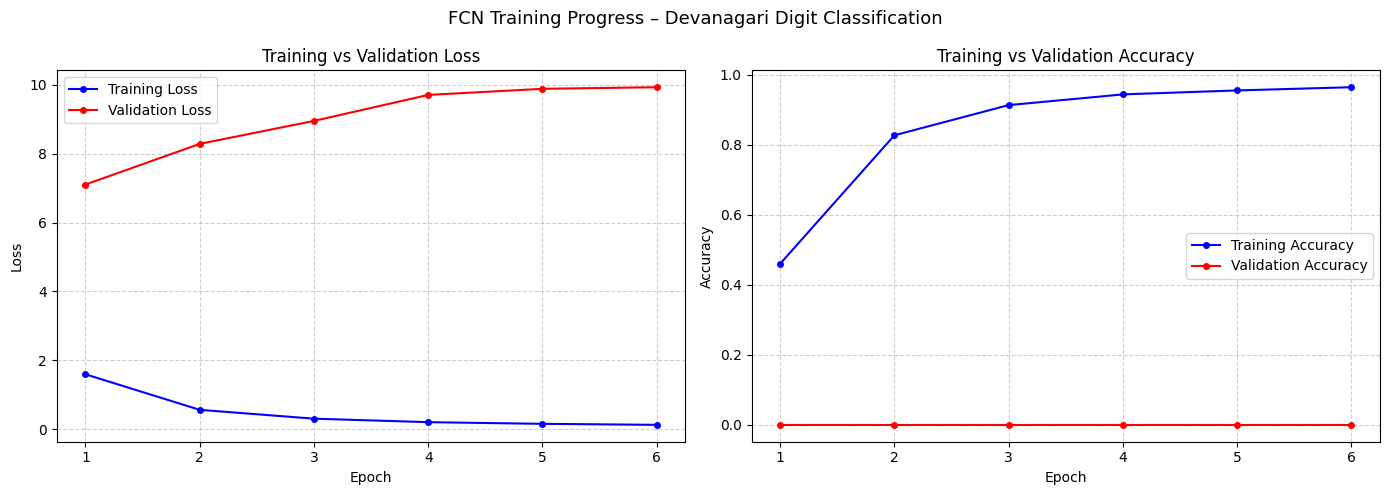

Best val accuracy : 0.00%  (epoch 1)
Best val loss     : 7.1055  (epoch 1)


In [ ]:
# Plot training curves
train_loss  = history.history["loss"]
val_loss    = history.history["val_loss"]
train_acc   = history.history["accuracy"]
val_acc     = history.history["val_accuracy"]
epoch_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epoch_range, train_loss, "b-o", label="Training Loss",   markersize=4)
axes[0].plot(epoch_range, val_loss,   "r-o", label="Validation Loss", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Accuracy curve
axes[1].plot(epoch_range, train_acc, "b-o", label="Training Accuracy",   markersize=4)
axes[1].plot(epoch_range, val_acc,   "r-o", label="Validation Accuracy", markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("FCN Training Progress – Devanagari Digit Classification", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best val accuracy : {max(val_acc)*100:.2f}%  (epoch {val_acc.index(max(val_acc))+1})")
print(f"Best val loss     : {min(val_loss):.4f}  (epoch {val_loss.index(min(val_loss))+1})")

In [ ]:
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")

Evaluating on test set...
94/94 - 0s - 3ms/step - accuracy: 0.5790 - loss: 2.0901
  Test Loss     : 2.0901
  Test Accuracy : 57.90%


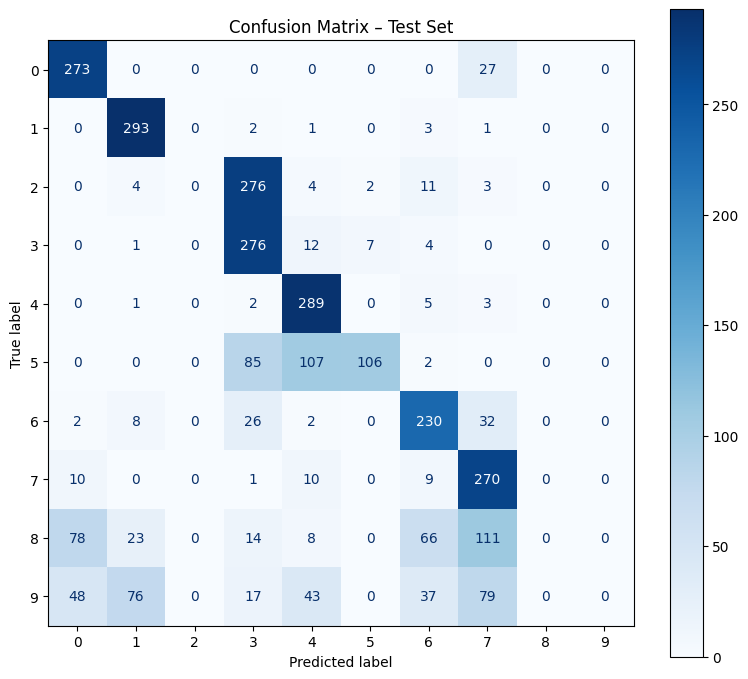

In [ ]:
# Confusion Matrix
y_pred_probs  = model.predict(x_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm   = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[str(i) for i in range(NUM_CLASSES)])

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.show()

In [ ]:
# Save
SAVE_PATH = "/content/devnagari_fcn_model.h5"
model.save(SAVE_PATH)
file_size_mb = os.path.getsize(SAVE_PATH) / (1024 ** 2)
print(f"Model saved  : {SAVE_PATH}")
print(f"File size    : {file_size_mb:.2f} MB")

Model saved  : /content/devnagari_fcn_model.h5
File size    : 1.11 MB


In [ ]:
# Load
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print("Model loaded successfully.")
loaded_model.summary()

Model loaded successfully.


Model: "FCN_Devanagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Re-evaluate loaded model
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_accuracy * 100:.2f}%")

match = np.isclose(test_accuracy, loaded_accuracy, atol=1e-5)
print(f"\n Accuracy matches original model: {match}")

94/94 - 1s - 6ms/step - accuracy: 0.5790 - loss: 2.0901
  Loaded Model Test Loss     : 2.0901
  Loaded Model Test Accuracy : 57.90%

 Accuracy matches original model: True


In [ ]:
# Predict on full test set
predictions     = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

print(f"Predicted label for first image : {predicted_labels[0]}")
print(f"True label for first image      : {true_labels[0]}")
print(f"Confidence                      : {predictions[0][predicted_labels[0]]*100:.2f}%")

Predicted label for first image : 7
True label for first image      : 0
Confidence                      : 31.70%


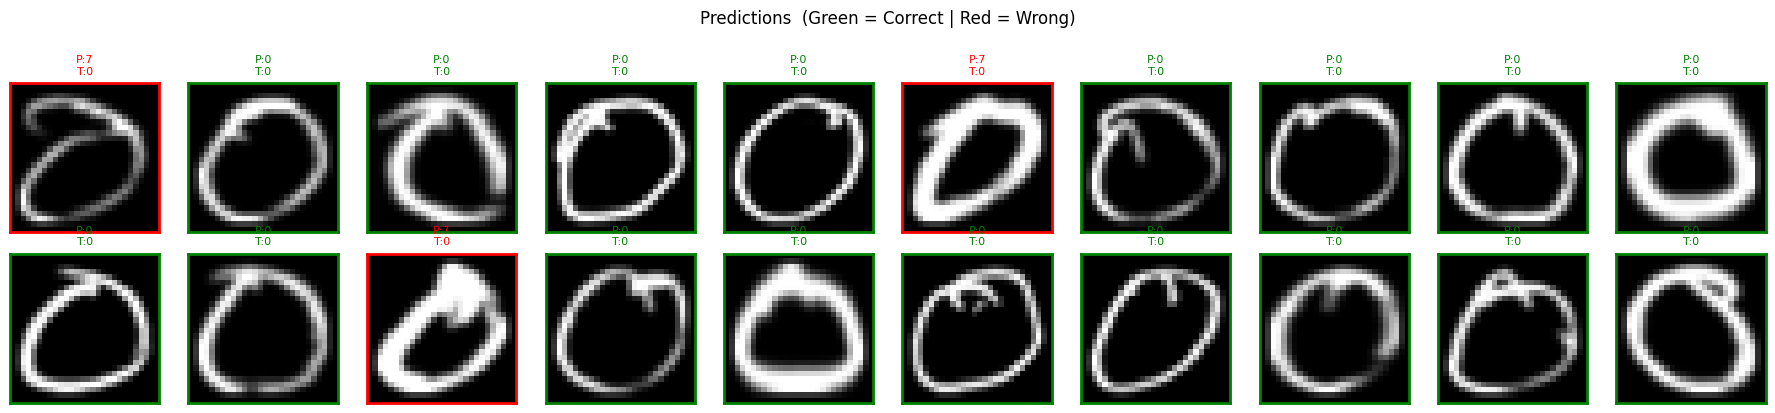

In [ ]:
# Visualise 20 predictions (green = correct, red = wrong)
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
axes = axes.flatten()

for i in range(20):
    axes[i].imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    correct = (predicted_labels[i] == true_labels[i])
    color   = "green" if correct else "red"
    axes[i].set_title(f"P:{predicted_labels[i]}\nT:{true_labels[i]}",
                      color=color, fontsize=8)
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle("Predictions  (Green = Correct | Red = Wrong)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

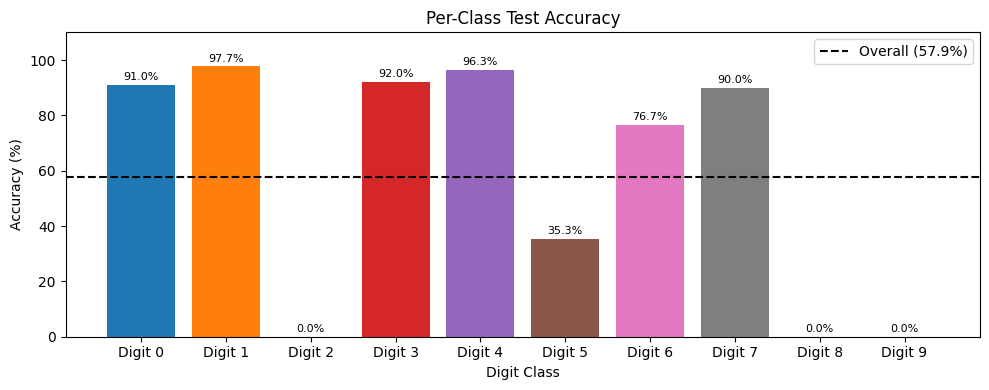

In [ ]:
# Per-class accuracy breakdown
per_class_correct = np.zeros(NUM_CLASSES)
per_class_total   = np.zeros(NUM_CLASSES)

for true, pred in zip(true_labels, predicted_labels):
    per_class_total[true] += 1
    if true == pred:
        per_class_correct[true] += 1

per_class_acc = per_class_correct / per_class_total * 100

plt.figure(figsize=(10, 4))
bars = plt.bar([f"Digit {i}" for i in range(NUM_CLASSES)],
               per_class_acc, color=plt.cm.tab10.colors)
plt.axhline(y=test_accuracy * 100, color="black", linestyle="--",
            linewidth=1.5, label=f"Overall ({test_accuracy*100:.1f}%)")
plt.xlabel("Digit Class")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Test Accuracy")
plt.ylim(0, 110)
plt.legend()
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

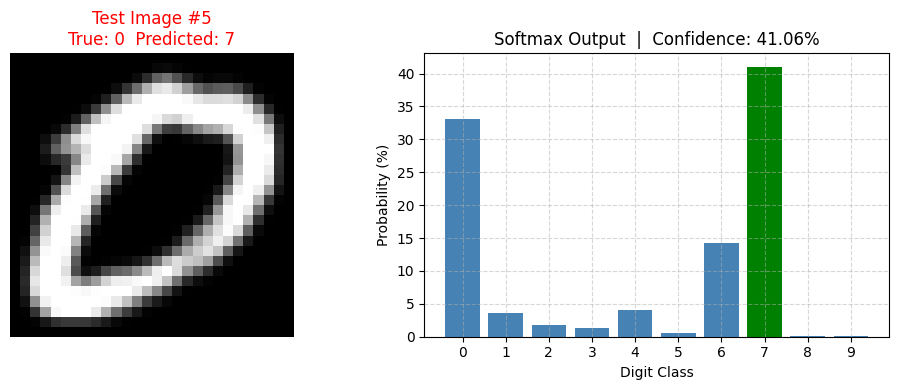

In [ ]:
# Softmax probability chart for a single image
SAMPLE_IDX   = 5   # can change index to explore different images

sample_probs = predictions[SAMPLE_IDX]
sample_pred  = predicted_labels[SAMPLE_IDX]
sample_true  = true_labels[SAMPLE_IDX]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(x_test[SAMPLE_IDX].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
ax1.set_title(f"Test Image #{SAMPLE_IDX}\nTrue: {sample_true}  Predicted: {sample_pred}",
              color="green" if sample_pred == sample_true else "red")
ax1.axis("off")

colours = ["green" if i == sample_pred else "steelblue" for i in range(NUM_CLASSES)]
ax2.bar(range(NUM_CLASSES), sample_probs * 100, color=colours)
ax2.set_xticks(range(NUM_CLASSES))
ax2.set_xlabel("Digit Class")
ax2.set_ylabel("Probability (%)")
ax2.set_title(f"Softmax Output  |  Confidence: {sample_probs[sample_pred]*100:.2f}%")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Final summary
print("FINAL RESULTS SUMMARY")
print(f"  Training samples    : {x_train.shape[0]}")
print(f"  Test samples        : {x_test.shape[0]}")
print(f"  Total parameters    : {model.count_params():,}")
print(f"  Epochs trained      : {len(history.history['loss'])}")
print(f"  Best val accuracy   : {max(val_acc)*100:.2f}%")
print(f"  Test Loss           : {test_loss:.4f}")
print(f"  Test Accuracy       : {test_accuracy*100:.2f}%")
print(f"  Saved model         : {SAVE_PATH}")

FINAL RESULTS SUMMARY
  Training samples    : 17000
  Test samples        : 3000
  Total parameters    : 94,154
  Epochs trained      : 6
  Best val accuracy   : 0.00%
  Test Loss           : 2.0901
  Test Accuracy       : 57.90%
  Saved model         : /content/devnagari_fcn_model.h5
